In [1]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense,Conv2D,MaxPooling2D, GRU
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import io
import scipy.ndimage

In [2]:
upload =files.upload()
stock_data = pd.read_csv(io.BytesIO(upload['close price-case study II.csv']))
stock_data.head()

,Date,Iran Khodro,S*Mobarakeh Steel,S*Isf. Oil Ref.Co.,Gol-E-Gohar.,S*F. & Kh. Cement,Rouz Darou P.,Pars Switch,Iran China Clay,S*IRI Marine Co.,I. Pegah Dairy,Int. Const.,S*Sabet Khorasan,Soufian Cement,S*Saipa,S*I. N. C. Ind.
0,20251022,526,2739,4865,2031,16900,9200,4992,20450,5580,8670,536,1975,142610,484,7870
1,20251021,518,2712,4762,1972,16920,9230,4977,20500,5430,8570,534,1918,139030,484,7820
2,20251020,529,2754,4645,2010,17010,9240,4968,20440,5460,8490,520,1884,135800,494,7800
3,20251019,517,2816,4721,2042,17220,9270,4960,20480,5580,8590,510,1906,131940,499,7920
4,20251018,517,2791,4649,2014,17180,9310,4949,20410,5630,8550,521,1898,128170,485,7740


In [3]:
stock_data = stock_data.sort_values(by='Date', ascending= True)
stock_data.head()

,Date,Iran Khodro,S*Mobarakeh Steel,S*Isf. Oil Ref.Co.,Gol-E-Gohar.,S*F. & Kh. Cement,Rouz Darou P.,Pars Switch,Iran China Clay,S*IRI Marine Co.,I. Pegah Dairy,Int. Const.,S*Sabet Khorasan,Soufian Cement,S*Saipa,S*I. N. C. Ind.
1677,20181022,2685,6219,10845,8269,1592,2250,5991,11934,4995,9478,1062,3568,3454,1144,4579
1676,20181023,2587,6082,10845,7952,1530,2193,5990,11512,4859,9476,1045,3391,3454,1090,4472
1675,20181024,2526,5989,10002,7780,1460,2162,5953,11119,4641,9476,996,3224,3454,1036,4364
1674,20181027,2418,5959,9606,7791,1388,2059,5959,10869,4614,9466,969,3065,3453,1045,4286
1673,20181028,2451,5956,9467,7878,1344,2119,5948,10610,4639,9454,966,3173,3393,1080,4302


In [4]:
num_columns=stock_data.shape[1]
num_rows=stock_data.shape[0]
raw_prices = np.zeros((num_rows,num_columns-1))
for i in range(1,num_columns,1):
  for j in range(0,num_rows):
     raw_prices[j,i-1] = stock_data.iloc[j,i]

In [5]:
Relative_difference = np.zeros((num_columns-1,num_rows -1))
for i in range(num_columns-1):
  for j in range(num_rows-1):
        Relative_difference[i,j] =(raw_prices[j+1,i]- raw_prices[j,i])/raw_prices[j,i]

In [6]:
clean_RD =[]
jump_index=[]
num_jump = []
for i in range(num_columns-1):
  clean_RD.append([])
  jump_index.append([])
  k=0
  for j in range(len(Relative_difference[i])):
    if abs(Relative_difference[i][j]) >= 0.1 or abs(Relative_difference[i][j]) <= 0.00000000000000001:
      jump_index[i].append(j)
      k+= 1
      j+=1
    else:
      clean_RD[i].append(Relative_difference[i][j])
  num_jump.append(k)

In [7]:
clean_prices = []
for i in range(num_columns-1):
    clean_prices.append([])
    new_lenghth = len(Relative_difference[i])-num_jump[i]
    #print(new_lenghth)
    p = np.zeros(new_lenghth+1)
    p[0] = raw_prices[0,i]
    for l in range(1,new_lenghth+1):
        p[l] = p[l-1]*(1+clean_RD[i][l-1])
    clean_prices[i].append(p)

In [8]:
def remove_nan_element (vector):
  non_nan_indices = ~np.isnan(vector)
  vector_without_nan = vector[non_nan_indices]
  return vector_without_nan

#Separate the last_90_ for prediction
last_90_RD_clean =np.zeros((90,num_columns-1))
for i in range (num_columns-1):
  vector_without_nan=(remove_nan_element(np.array(clean_RD[i])))
  last_90_RD_clean[:,i] = vector_without_nan[-90:]


#Separate the last_90_ for Plt
last_90_prices_clean =np.zeros((90,num_columns-1))
for i in range (num_columns-1):
   vector_without_nan=(remove_nan_element(clean_prices[i][0]))
   last_90_prices_clean[:,i] = vector_without_nan[-90:]

In [9]:
#Relative_difference without the last 90 days
train_RD_clean = []
for i in range (num_columns-1):
   vector_without_nan=remove_nan_element(np.array(clean_RD[i]))
   train_RD_clean.append(vector_without_nan[:-90])

# close price without the last 90 days
train_prices_clean = []
for i in range (num_columns-1):
   vector_without_nan=remove_nan_element(clean_prices[i][0])
   train_prices_clean.append(vector_without_nan[:-90])

In [10]:
def split_to_squenses(data,step,future):
   X, Y = [], []
   for i in range(len(data)-step-future):
     d=i+step
     X.append(data[i:d])
     Y.append(data[d:(d+future)])
   return np.array(X), np.array(Y)

In [11]:
from random import choices
def bootstraping(xtrain, nboot):
  indexes = []
  length = xtrain.shape[0]
  indices = list(range(1, length))
  for i in range(nboot):
    boot = choices(indices, k = length)
    indexes.append(boot)
  return indexes

In [12]:
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Reshape

def create_gru_model(x_train,y_train):
   model = Sequential()
   model.add(GRU(
    units=64,                
    activation='tanh',       
    return_sequences=False,
    input_shape=(x_train.shape[1], x_train.shape[2])
   ))
   #model.add(Dropout(0.1))
   model.add(Dense(90))       
   model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='huber',
    metrics=['mse'])
   return model

In [14]:
# We create indices for 35 scenarios and then you choose 5, 10, 15, 20, 25 , 30 and 35 scenarios from that.
#for i,share in enumerate(train_RD_clean):
#  x_train,y_train = split_to_squenses(share,900,90)
#  df_index = pd.DataFrame(bootstraping(x_train,35))
#  filepath = f'E:/desktop/javadi-soleimani/15 assets/indexes_35/inds {i}.xlsx'
#  df_index.to_excel(filepath, index=False)

In [15]:
# Download once and use it for everyone.
#!zip -r /content/all_results_gru.zip /content
#from google.colab import files
#files.download("/content/all_results_gru.zip")

In [13]:
inds = []
for sh in range(num_columns-1):
  upload =files.upload()
  inds.append(pd.read_excel(io.BytesIO(upload[f'inds {sh}.xlsx'])))

In [15]:
nboot = 15 #number of Scenarios

In [16]:
#prediction_y_not_boot2 = []
#prediction_y_boot2 = []
#num_assets = 15
#for index in range(num_assets):
# prediction_y_not_boot2.append([np.array(pd.read_excel(f'Prediction_not_boot2 {index+1}.xlsx')).reshape((90,))])
# prediction_y_boot2.append([])
# for b in range(nboot):
#   prediction_y_boot2[index].append([np.array(pd.read_excel(f'Prediction2 {index+1}{b+1}.xlsx')).reshape((90,))])

In [20]:
 import warnings
 history_boot2 = []
 prediction_y_not_boot2 = []
 history_not_boot2 = []
 prediction_y_boot2 = []
 model2 = []
 modelb2 = []
 cntr1 = 0
 for index,share in enumerate(train_RD_clean):
   cntr2 = 0
   print("property",cntr1+1)
   x_train,y_train = split_to_squenses(share,900,90)
   x_train = np.reshape(x_train, (x_train.shape[0],1 , x_train.shape[1]))
   length = len(train_RD_clean[cntr1])
   x_test = train_RD_clean[cntr1][(length - 900):length]
   x_test = np.reshape(x_test, (1,1, len(x_test)))
   model2.append(create_gru_model(x_train,y_train))
   warnings.filterwarnings("ignore")
   fited = model2[cntr1].fit(x_train, y_train, epochs=100, batch_size=100, shuffle=False,verbose=0)
   history_not_boot2.append(fited)
   warnings.filterwarnings("ignore")
   yy = model2[cntr1].predict(x_test)
   yy_array = np.array(yy)
#   df_PNB = pd.DataFrame(yy_array)
#   filepath = f'Prediction_not_boot2 {index+1}.xlsx'
#   df_PNB.to_excel(filepath, index=False)
   prediction_y_not_boot2.append(yy)
   modelb2.append([])
   history_boot2.append([])
   prediction_y_boot2.append([])
   for b in range(nboot):
     print("bootstrap",cntr2+1)
     indx = np.asarray(inds[cntr1])[b,:]
     x_boot = x_train[indx,:]
     y_boot = y_train[indx,:]
     modelb2[cntr1].append(create_gru_model(x_boot,y_boot))
     warnings.filterwarnings("ignore")
     fited = modelb2[cntr1][cntr2].fit(x_boot, y_boot, epochs=100, batch_size=100, shuffle=False,verbose=0)
     history_boot2[cntr1].append(fited)
     warnings.filterwarnings("ignore")
     yy = modelb2[cntr1][cntr2].predict(x_test)
     yy_array = np.array(yy)
#     df_PB = pd.DataFrame(yy_array)
#     filepath = f'Prediction2 {index+1}{b+1}.xlsx'
#     df_PB.to_excel(filepath, index=False)
     prediction_y_boot2[cntr1].append(yy)
     cntr2 = cntr2 + 1
   cntr1 = cntr1 + 1

property 1


C:\Users\LENOVO.PIESC\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
bootstrap 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
bootstrap 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
bootstrap 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
bootstrap 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
bootstrap 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
bootstrap 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
bootstrap 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
bootstrap 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
bootstrap 9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
bootstrap 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
bootstrap 11
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
bootstrap 12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
bootstrap 13
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
bootstrap 14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
bootstrap 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
property 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
bootstrap 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 815ms/step
bootstrap 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
bootstrap 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

In [21]:
#for sh in range(0,9):
#  filepath = f'inds {sh}.xlsx'
#  df1 = pd.DataFrame(inds[sh])
#  df1.to_excel(filepath,index=False)

In [22]:
#for sh in range(9):
#  inds[sh] = np.asarray(inds[sh])
#  print(inds[sh].shape)

In [23]:
#!zip -r /content/all_results_gru.zip /content
#from google.colab import files
#files.download("/content/all_results_gru.zip")
#prediction_y_not_boot2[0][0].shape, last_90_RD_clean[:,0].shape

In [17]:
num_assets = 15
for i in range(num_assets):
   print('mse for without bootstrap asset',i, '=')
   print(sum((prediction_y_not_boot2[i][0] - last_90_RD_clean[:,i])**2))
   print('mae for without bootstrap asset',i, '=')
   print(sum(abs(prediction_y_not_boot2[i][0] - last_90_RD_clean[:,i])))

mse for without bootstrap asset 0 =
0.0555439256807088
mae for without bootstrap asset 0 =
1.870209162531566
mse for without bootstrap asset 1 =
0.07606640542036654
mae for without bootstrap asset 1 =
2.047938532625185
mse for without bootstrap asset 2 =
0.08757776937656546
mae for without bootstrap asset 2 =
2.308058132884974
mse for without bootstrap asset 3 =
0.0384226069799331
mae for without bootstrap asset 3 =
1.598975146852519
mse for without bootstrap asset 4 =
0.0630351838703187
mae for without bootstrap asset 4 =
2.0087748184098326
mse for without bootstrap asset 5 =
0.032589333832433495
mae for without bootstrap asset 5 =
1.335110732616829
mse for without bootstrap asset 6 =
0.021910894175612802
mae for without bootstrap asset 6 =
1.148806961706114
mse for without bootstrap asset 7 =
0.04514101439434391
mae for without bootstrap asset 7 =
1.6440102249045034
mse for without bootstrap asset 8 =
0.0680758938346956
mae for without bootstrap asset 8 =
2.0391324071627186
mse for w

In [18]:
num_assets = 15
Mse =[]
Mae =[]
for i in range (num_assets):
  Mse.append([])
  Mae.append([])
  for j in range(nboot):
     Mse[i].append(sum(prediction_y_boot2[i][j][0] - last_90_RD_clean[:,i])**2)
     Mae[i].append(sum(abs(prediction_y_boot2[i][j][0] - last_90_RD_clean[:,i])))

In [19]:
for i in range (num_assets):
   Mean_Mse= np.mean(Mse[i])
   STD_Mse = np.std(Mse[i])
   print(Mean_Mse, STD_Mse)

0.029674879112654304 0.030204228564400182
0.16760187346137762 0.09934488965275078
0.036749639062315466 0.043088004099825494
0.03014168229116866 0.03264932252277908
0.13975942984878464 0.06602158215427938
0.024412612235101664 0.03150409473664792
0.019720617461299463 0.021910481274138846
0.3073375424870186 0.14055075400442898
0.6709868330903478 0.26050402202498885
0.020409410574324452 0.03261454936236414
0.08704794865044185 0.0789415431801868
0.05453462230286199 0.05203661166365318
0.09105126237942396 0.05264902904731001
0.019671496511555014 0.0248404799863231
0.013164571709476203 0.013210792673052528


In [20]:
for i in range (num_assets):
   Mean_Mae= np.mean(Mae[i])
   STD_Mae = np.std(Mae[i])
   print(Mean_Mae, STD_Mae)

2.114397445560076 0.138321200943807
2.0698225525634886 0.13935159889584406
2.087727668879083 0.08637083574911954
1.5743787067870096 0.10565311462926065
1.9900244022813989 0.08907280547551037
1.4081131172163532 0.09518791630107656
1.2324498100721746 0.11874092065268177
1.5575493162412244 0.07214991320554774
2.0953763337657794 0.16607584161100067
1.6015113179647515 0.1289314462931175
2.0259547566449685 0.1312452349050797
1.833348780321402 0.09580368044968109
1.9479314295903847 0.11176999293673405
2.0183803790077874 0.1049195767992892
1.778492210403696 0.08873753192176181


In [21]:
num_assets = 15
price_prediction_not_boot2 = []
#for i in range(num_columns-1):
for i in range(num_assets):
    p = np.zeros(90)
    p[0] = train_prices_clean[i][len(Relative_difference[1])-num_jump[i]-90]
    for k in range(1,90):
        p[k] = p[k-1]*(1+prediction_y_not_boot2[i][0][k-1])
    price_prediction_not_boot2.append(p)

In [22]:
price_prediction2 = []
#for i in range(num_columns-1):
for i in range(num_assets):
    p = np.zeros((nboot,90))
    for j in range(nboot):
        p[j,0] = train_prices_clean[i][len(Relative_difference[1])-num_jump[i]-90]
        for k in range(1,90):
            p[j,k] = p[j,k-1]*(1+prediction_y_boot2[i][j][0][k-1])
    price_prediction2.append(p)

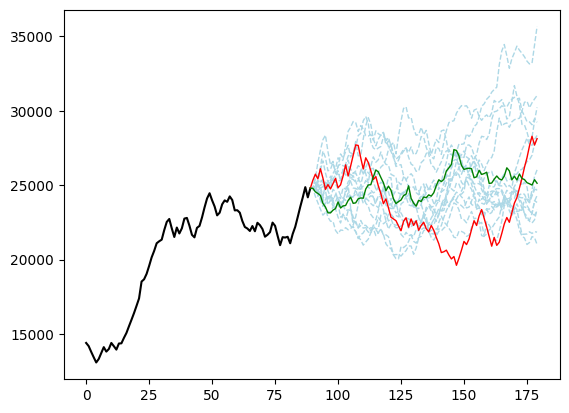

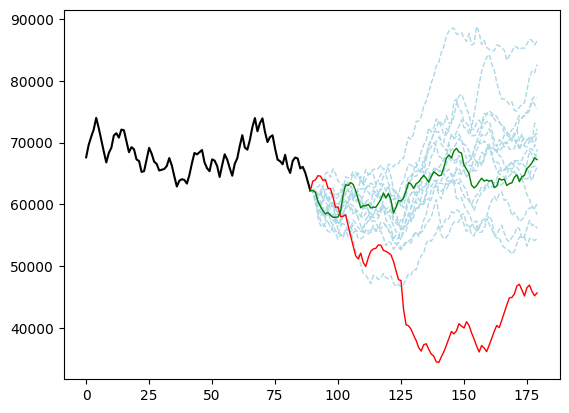

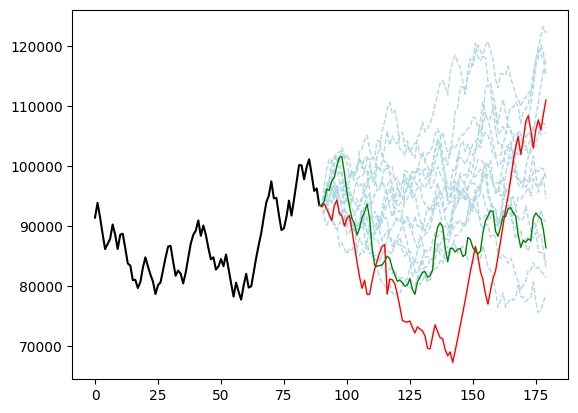

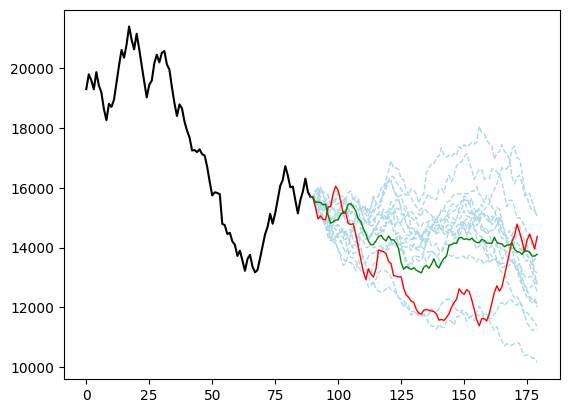

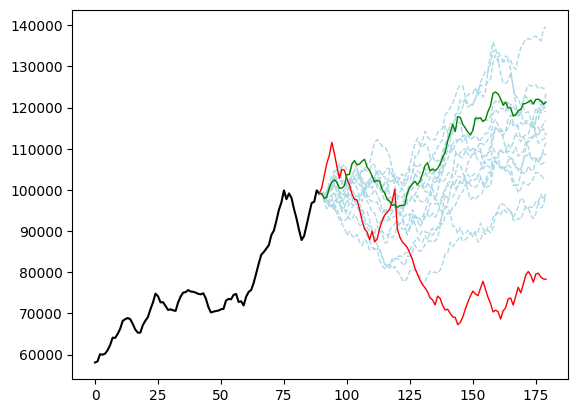

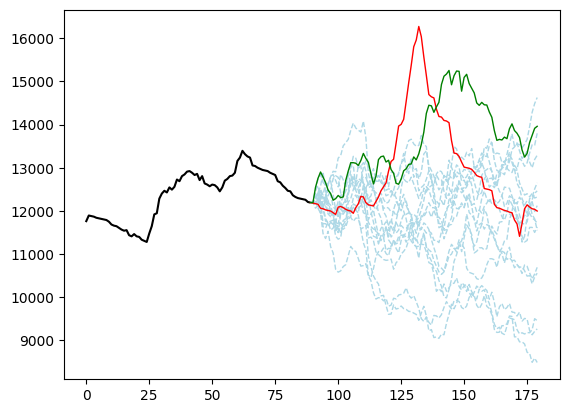

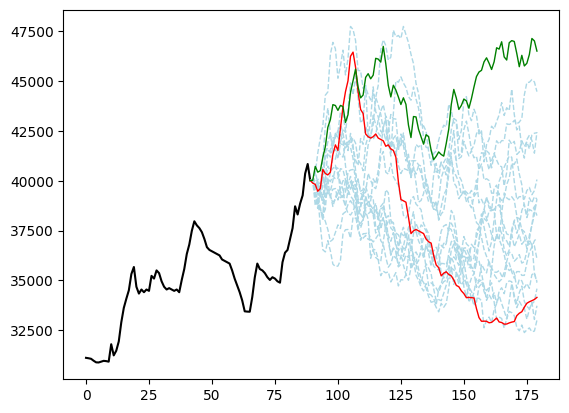

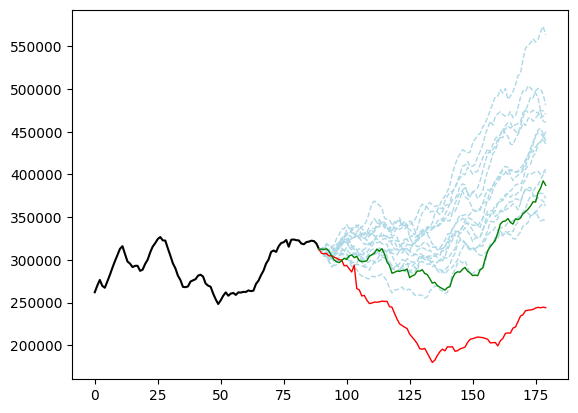

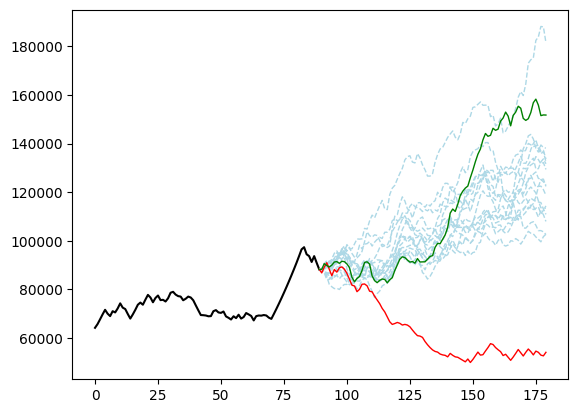

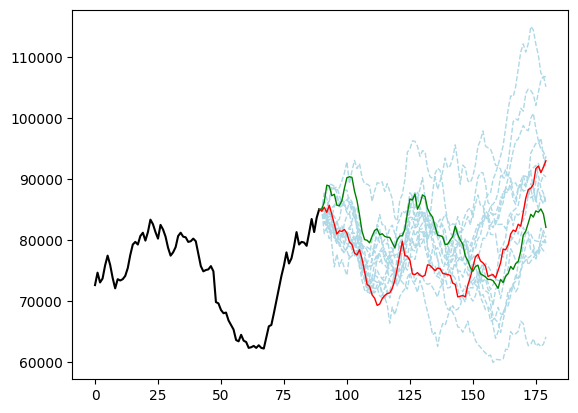

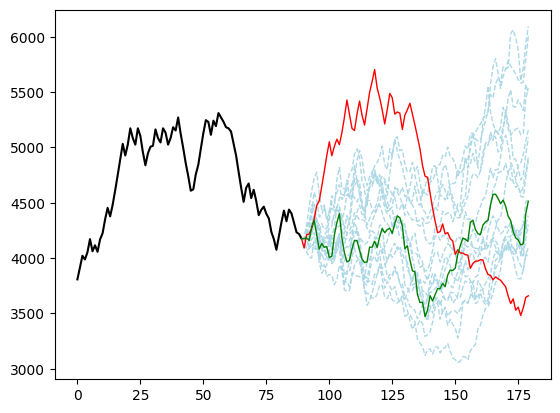

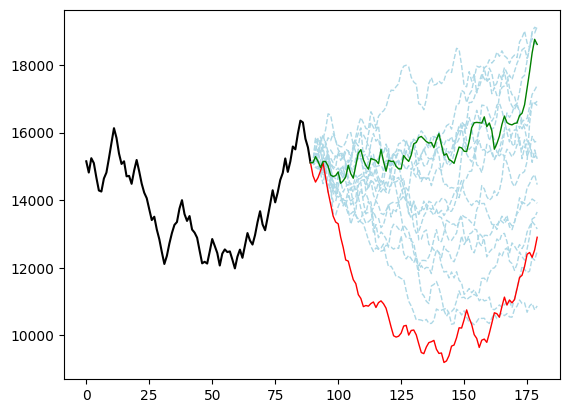

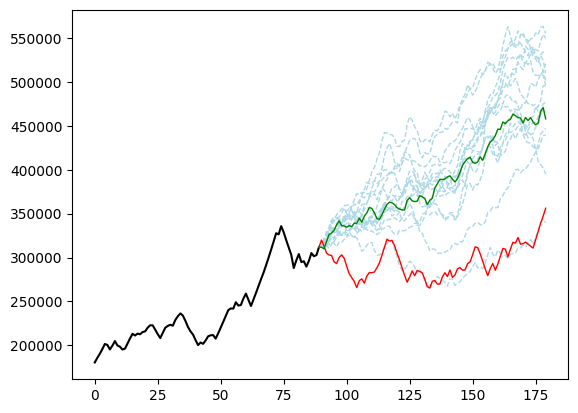

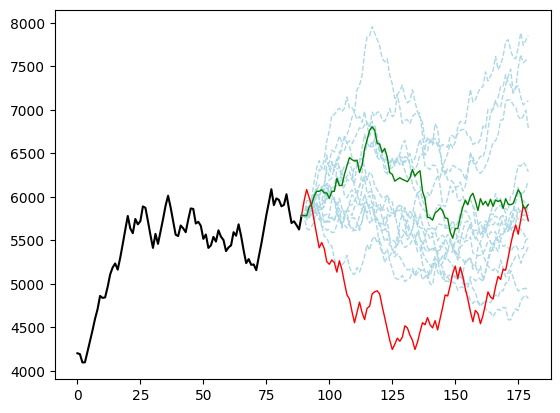

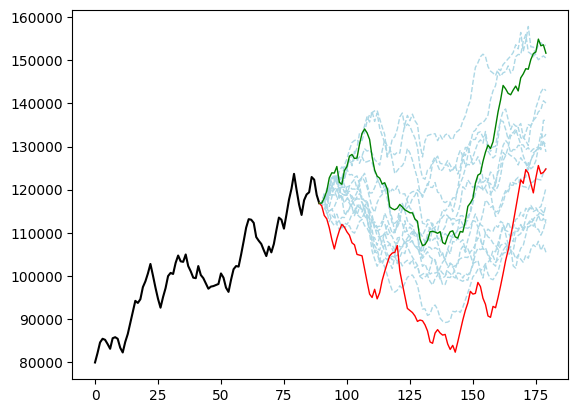

In [24]:
numboot = 15 # Do it separately for 5, 10, 15, 20, 25 , 30 and 35.
for i in range(num_assets):
  end = len(train_prices_clean[i])
  beg = end - 90
  time = range(len(train_prices_clean[i][beg:end]))
  plt.plot(time,train_prices_clean[i][beg:end],color="black")
  tim = range(len(train_prices_clean[i][beg:end])-1,len(train_prices_clean[i][beg:end])+90)
  for j in range(0,numboot):
    a = np.hstack([train_prices_clean[i][end-1],price_prediction2[i][j][:]])
    plt.plot(tim, a, color = 'lightblue', linestyle='dashed', linewidth=1)
  b = np.hstack([train_prices_clean[i][end-1],last_90_prices_clean[:,i]])
  plt.plot(tim,b,color = "red", linewidth=1)
  c = np.hstack([train_prices_clean[i][end-1],price_prediction_not_boot2[i][:]])
  plt.plot(tim,c,color = "green", linewidth=1)
  plt.savefig(f'stock_c_{i+1}_{numboot}.jpg')
  plt.show()
  #files.download(f'stock_g {i+1}_{numboot}.jpg')

In [27]:
def calculate_mean_cov(y_pred, nboot):
  mean = np.zeros((nboot, num_assets))
  std = np.zeros((nboot,num_assets))
  for i in range(num_assets):
    for j in range(nboot):
      mean[j,i] = np.mean(y_pred[i][j])
      std [j,i] = np.std(y_pred[i][j])
  Covariance_Matrix = np.zeros((nboot,num_assets,num_assets))
  for j in range(nboot):
    Cov_between = np.array([y_pred[i][j] for i in range(num_assets)])
    CC= Cov_between.reshape(Cov_between.shape[0], Cov_between.shape[2])
    Covariance_Matrix[j,:,:] = np.cov(CC)
  return mean, std, Covariance_Matrix

nboot = 15
m2_30, s2_30, c2_30 = calculate_mean_cov(prediction_y_boot2,nboot)


In [ ]:
#dfm2 = pd.DataFrame(m2)
## save to xlsx file
#filepath = 'm2.xlsx'
#dfm2.to_excel(filepath, index=False)
#files.download('m2.xlsx')
#dfs2 = pd.DataFrame(s2)
#filepath = 's2.xlsx'
#dfs2.to_excel(filepath, index=False)

#for j in range(15):
#  dfc2 = pd.DataFrame(c2[j,:,:])
#  filepath = f'c2 {j+1}.xlsx'
#  dfc2.to_excel(filepath, index=False)
#  files.download(filepath)

In [30]:
#!pip install cvxopt

In [31]:
#!pip install scipy

In [32]:
#!pip install xlrd

In [28]:
import numpy as np
from scipy.optimize import minimize , Bounds
from cvxopt import matrix, solvers
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
#from google.colab import files
import os
import io
import xlrd

In [30]:
Mean30 = m2_30
covariance30 = []
for i in range(nboot):
  covariance30.append(c2_30[i,:,:])

In [32]:
MEAN30 = []
for i in range (nboot):
    Mean_row30 =np.zeros((1,num_assets))
    Mean_row30[0,:] = Mean30[i,:]
    MEAN30.append(Mean_row30)

In [33]:
import random

In [34]:
#Senario_Optimization
old_settings = solvers.options.copy()
solvers.options['show_progress'] = False
Optimal_value30 =[]
Optimal_solution30 =[]
for i in range(nboot):
  sigma = covariance30[i]
  Q = matrix(sigma, tc='d')
  P = matrix(-MEAN30[i], tc='d').T
  G = matrix(-np.eye(num_assets), tc='d')
  h = matrix(np.zeros(num_assets), tc='d')
  A = matrix(np.ones(num_assets), tc='d').T
  b = matrix(1.0)
  Optimal_value_Lambda = []
  Optimal_solution_Lambda = []
  for Lambda in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]: 
      sol = solvers.qp(2*Lambda*Q,(1-Lambda)*P,G,h,A,b)
      Optimal_value_Lambda.append(sol['primal objective'])
      Optimal_solution_Lambda.append(sol['x'])
  Optimal_solution30.append(Optimal_solution_Lambda)
  Optimal_value30.append(Optimal_value_Lambda)
solvers.options.update(old_settings)

In [35]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for j in range(nboot):
   print("Bootstrap sample",j+1)
   for i in range(9):
    print("lambda =", Lambda_list[i])
    print(Optimal_solution30[j][i][:])

Bootstrap sample 1
lambda = 0.1
[ 3.12e-07]
[ 2.67e-07]
[ 2.32e-07]
[ 2.87e-07]
[ 3.93e-07]
[ 3.07e-07]
[ 2.95e-07]
[ 3.81e-07]
[ 1.00e+00]
[ 3.71e-07]
[ 3.82e-07]
[ 1.63e-07]
[ 2.19e-07]
[ 2.69e-07]
[ 6.16e-08]

lambda = 0.2
[ 3.43e-07]
[ 2.92e-07]
[ 2.58e-07]
[ 3.15e-07]
[ 4.30e-07]
[ 3.39e-07]
[ 3.27e-07]
[ 4.02e-07]
[ 1.00e+00]
[ 3.99e-07]
[ 4.16e-07]
[ 1.83e-07]
[ 2.24e-07]
[ 2.99e-07]
[ 6.37e-08]

lambda = 0.3
[ 3.70e-07]
[ 3.24e-07]
[ 2.83e-07]
[ 3.39e-07]
[ 4.67e-07]
[ 3.68e-07]
[ 3.56e-07]
[ 4.12e-07]
[ 1.00e+00]
[ 4.21e-07]
[ 4.52e-07]
[ 2.03e-07]
[ 2.22e-07]
[ 3.25e-07]
[ 6.66e-08]

lambda = 0.4
[ 3.85e-07]
[ 3.72e-07]
[ 2.99e-07]
[ 3.49e-07]
[ 4.96e-07]
[ 3.84e-07]
[ 3.74e-07]
[ 3.94e-07]
[ 1.00e+00]
[ 4.22e-07]
[ 4.84e-07]
[ 2.18e-07]
[ 2.02e-07]
[ 3.41e-07]
[ 7.18e-08]

lambda = 0.5
[ 3.54e-07]
[ 4.55e-07]
[ 2.85e-07]
[ 3.17e-07]
[ 4.87e-07]
[ 3.58e-07]
[ 3.53e-07]
[ 2.99e-07]
[ 1.00e+00]
[ 3.62e-07]
[ 4.89e-07]
[ 2.11e-07]
[ 1.19e-07]
[ 3.20e-07]
[ 8.11e-08]

lambda = 0.

In [36]:
OPT_X =[]
for l in range(nboot):
  OX =np.zeros((num_assets,num_assets))
  for n in range(9):
    for k in range(num_assets):
      OX[k,n]=Optimal_solution30[l][n][k]
  OPT_X.append(OX)

In [37]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in range(nboot):
  print("Bootstrap sample",i+1)
  sigma = covariance30[i]
  for k in range(9):
    print("Lambda =", Lambda_list[k])
    a = np.dot(OPT_X[i][:,k].T, sigma @ OPT_X[i][:,k])
    print(a)

Bootstrap sample 1
Lambda = 0.1
0.00040353390639027905
Lambda = 0.2
0.00040353361563022776
Lambda = 0.3
0.00040353335173648475
Lambda = 0.4
0.0004035331890330422
Lambda = 0.5
0.00040353340390544015
Lambda = 0.6
0.00040353276974877574
Lambda = 0.7
0.0003696482812143401
Lambda = 0.8
0.00017003923369978438
Lambda = 0.9
7.104925567512958e-05
Bootstrap sample 2
Lambda = 0.1
0.00018352545429991862
Lambda = 0.2
0.0001835253443640306
Lambda = 0.3
0.00018352492036345595
Lambda = 0.4
0.00018352461017108658
Lambda = 0.5
0.0001835247706824677
Lambda = 0.6
0.00018352407787208862
Lambda = 0.7
0.00018124248222579206
Lambda = 0.8
0.00011368055985902571
Lambda = 0.9
8.250798604895654e-05
Bootstrap sample 3
Lambda = 0.1
0.00021030655756762326
Lambda = 0.2
0.00021030636053319678
Lambda = 0.3
0.00021030615675979512
Lambda = 0.4
0.00021030597151443621
Lambda = 0.5
0.00021030586693065054
Lambda = 0.6
0.00021030600322062123
Lambda = 0.7
0.00021030706410830085
Lambda = 0.8
0.00021027850460389057
Lambda = 0.9


In [38]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for m in range(nboot):
  print("Bootstrap sample",m+1)
  for k in range(9):
    print("Lambda =", Lambda_list[k])
    u = np.dot(MEAN30[m], OPT_X[m][:,k])
    print(u)

Bootstrap sample 1
Lambda = 0.1
[0.00464521]
Lambda = 0.2
[0.00464521]
Lambda = 0.3
[0.00464521]
Lambda = 0.4
[0.00464521]
Lambda = 0.5
[0.00464521]
Lambda = 0.6
[0.00464521]
Lambda = 0.7
[0.00456875]
Lambda = 0.8
[0.0039756]
Lambda = 0.9
[0.00340964]
Bootstrap sample 2
Lambda = 0.1
[0.00469901]
Lambda = 0.2
[0.00469901]
Lambda = 0.3
[0.004699]
Lambda = 0.4
[0.004699]
Lambda = 0.5
[0.004699]
Lambda = 0.6
[0.004699]
Lambda = 0.7
[0.00469357]
Lambda = 0.8
[0.00449131]
Lambda = 0.9
[0.00431489]
Bootstrap sample 3
Lambda = 0.1
[0.00596497]
Lambda = 0.2
[0.00596496]
Lambda = 0.3
[0.00596496]
Lambda = 0.4
[0.00596496]
Lambda = 0.5
[0.00596496]
Lambda = 0.6
[0.00596496]
Lambda = 0.7
[0.00596497]
Lambda = 0.8
[0.00596483]
Lambda = 0.9
[0.00540298]
Bootstrap sample 4
Lambda = 0.1
[0.00438486]
Lambda = 0.2
[0.00438486]
Lambda = 0.3
[0.00438485]
Lambda = 0.4
[0.00438485]
Lambda = 0.5
[0.00438486]
Lambda = 0.6
[0.00434489]
Lambda = 0.7
[0.00427744]
Lambda = 0.8
[0.00422703]
Lambda = 0.9
[0.0041865

In [39]:
for m in range(nboot):
  print("Bootstrap sample",m+1)
  for k in range(9):
    print("Lambda =", Lambda_list[k])
    print(Optimal_value30[m][k])

Bootstrap sample 1
Lambda = 0.1
-0.0041403374032249855
Lambda = 0.2
-0.0036354616827595034
Lambda = 0.3
-0.003130586415072541
Lambda = 0.4
-0.0026257117702400924
Lambda = 0.5
-0.002120838129574496
Lambda = 0.6
-0.0016159645620761613
Lambda = 0.7
-0.0011118697495032936
Lambda = 0.8
-0.0006590882828826783
Lambda = 0.9
-0.00027701975172685246
Bootstrap sample 2
Lambda = 0.1
-0.004210754049065141
Lambda = 0.2
-0.003722499715738791
Lambda = 0.3
-0.0032342429743564575
Lambda = 0.4
-0.002745987909828322
Lambda = 0.5
-0.002257735781747548
Lambda = 0.6
-0.001769484822091525
Lambda = 0.7
-0.0012812011056836236
Lambda = 0.8
-0.0008073175080147785
Lambda = 0.9
-0.0003572317681796215
Bootstrap sample 3
Lambda = 0.1
-0.005347439784629027
Lambda = 0.2
-0.004729910667446791
Lambda = 0.3
-0.004112381955304792
Lambda = 0.4
-0.0034948538440975774
Lambda = 0.5
-0.002877326602088105
Lambda = 0.6
-0.002259800568575734
Lambda = 0.7
-0.0016422766015458347
Lambda = 0.8
-0.0010247431609876675
Lambda = 0.9
-0.00

In [40]:
def objective_function_5(X0,Lambda,index_Lambda, nb):
    p_2 = 1/nb
    X = np.zeros((1,num_assets))
    for j in range(num_assets):
      X[0,j]=X0[j]
    total_sum = 0
    for i in range(nb):
        sigma = covariance30[i]
        mean_matrix = MEAN30[i]
        V_s = Optimal_value30[i][index_Lambda]
        term1 = np.dot(X, sigma @ X.T)
        term2 = np.dot(mean_matrix, X.T)
        term3 = V_s
        total_sum += p_2*(Lambda*term1 -(1-Lambda)*term2 - term3)**2

    return total_sum

In [41]:
#def constraint_1(s):
#    return s[0] + s[1] +s[2] + s[3] + s[4] +s[5] + s[6] + s[7] +s[8]  - 1

In [42]:
from scipy.optimize import LinearConstraint
linear_constraint = LinearConstraint([[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]], [1], [1])
#linear_constraint = LinearConstraint([[1,1,1,1,1,1,1,1,1,1,1,1]], [1], [1])

In [43]:
#Problem_5
nboot = 15
X_0 = [1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15]
#X_0 = [1/12,1/12,1/12,1/12,1/12,1/12,1/12,1/12,1/12,1/12,1/12,1/12]

# constarnt = {'type':'eq', 'fun': constraint_1}
Optimal_solution15_5=[]
Optimal_value15_5=[]
for i in range(9):
   random.seed(13600613)
   opt_solution = minimize(objective_function_5,X_0,args=(Lambda_list[i], i, nboot),bounds=Bounds(0,np.inf),constraints=[linear_constraint] , method='trust-constr')
   Optimal_solution15_5.append(opt_solution.x)
   Optimal_value15_5.append(opt_solution.fun)

print("Optimal solution for nboot=15:", Optimal_solution15_5)
print("Optimal value for nboot=15:", Optimal_value15_5)


Optimal solution for nboot=15: [array([0.00791361, 0.01015157, 0.00870469, 0.00487408, 0.01182232,
       0.0063335 , 0.00689299, 0.02168668, 0.16820479, 0.00777818,
       0.01269888, 0.00742722, 0.70844239, 0.00768412, 0.00938499]), array([0.00871347, 0.01114693, 0.0096087 , 0.00532288, 0.01296803,
       0.00705274, 0.00759468, 0.02358291, 0.15330466, 0.00861869,
       0.01378861, 0.00826906, 0.71110094, 0.00857823, 0.01034947]), array([0.00960904, 0.01242694, 0.01069088, 0.00586869, 0.01421005,
       0.0078046 , 0.00833919, 0.02820722, 0.1542996 , 0.00952366,
       0.01511997, 0.00913141, 0.69373945, 0.00953846, 0.01149085]), array([0.01162869, 0.01505942, 0.01312038, 0.00712284, 0.01781139,
       0.00968321, 0.01011159, 0.03358127, 0.15713437, 0.01168339,
       0.01845759, 0.01124595, 0.65724321, 0.01199155, 0.01412515]), array([0.01516278, 0.01941209, 0.01705335, 0.00932844, 0.02324755,
       0.01259646, 0.01322864, 0.04880458, 0.18494501, 0.01517376,
       0.02372291, 0.0

In [44]:
#Risk of Problem_5

nboot = 15
Risk15_5 =[]
p_2 = 1/nboot
for k in range(9):
  print("Lambda =", Lambda_list[k])
  total_sum = 0
  for i in range(nboot):
    sigma = covariance30[i]
    total_sum = total_sum + p_2 * np.dot(Optimal_solution15_5[k].T, sigma @ Optimal_solution15_5[k])
  print("risk for nboot=15 is ",total_sum)
  Risk15_5.append(total_sum)

Lambda = 0.1
risk for nboot=15 is  0.00011172669099579149
Lambda = 0.2
risk for nboot=15 is  0.00011093697297298046
Lambda = 0.3
risk for nboot=15 is  0.00010634694697581675
Lambda = 0.4
risk for nboot=15 is  9.71868426045054e-05
Lambda = 0.5
risk for nboot=15 is  7.951258078378655e-05
Lambda = 0.6
risk for nboot=15 is  1.8050813089011276e-05
Lambda = 0.7
risk for nboot=15 is  1.80508086747287e-05
Lambda = 0.8
risk for nboot=15 is  1.805080559353611e-05
Lambda = 0.9
risk for nboot=15 is  1.8050803885794176e-05


In [45]:
#Retern of Problem_5
nboot = 15
p_2 = 1/nboot
Retern15_5 =[]
for k in range(9):
  print("Lambda =", Lambda_list[k])
  total_sum = 0
  for i in range(nboot):
    total_sum = total_sum+ p_2 *np.dot(MEAN30[i], Optimal_solution15_5[k])
  print("return for nboot=15 is ", total_sum)
  Retern15_5.append(total_sum)

Lambda = 0.1
return for nboot=15 is  [0.00414261]
Lambda = 0.2
return for nboot=15 is  [0.00411205]
Lambda = 0.3
return for nboot=15 is  [0.00405537]
Lambda = 0.4
return for nboot=15 is  [0.0039268]
Lambda = 0.5
return for nboot=15 is  [0.00368533]
Lambda = 0.6
return for nboot=15 is  [0.00106285]
Lambda = 0.7
return for nboot=15 is  [0.00106284]
Lambda = 0.8
return for nboot=15 is  [0.00106284]
Lambda = 0.9
return for nboot=15 is  [0.00106284]


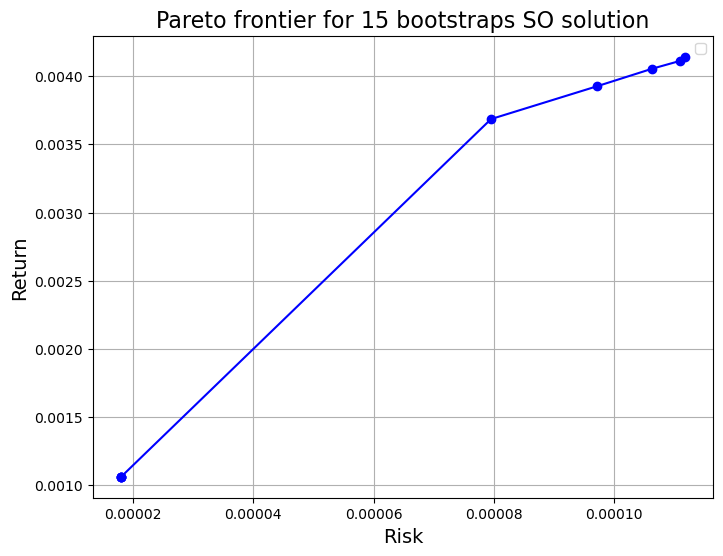

In [46]:
import matplotlib.pyplot as plt

SRisk15_5 = [x for x,_ in sorted(zip(Risk15_5,Retern15_5))]
SRetern15_5 = [x for _,x in sorted(zip(Risk15_5,Retern15_5))]

plt.figure(figsize=(8,6))
plt.plot(SRisk15_5, SRetern15_5, color='blue', marker='o', linestyle='-')
plt.xlabel('Risk', fontsize=14)
plt.ylabel('Return', fontsize=14)
plt.title('Pareto frontier for 15 bootstraps SO solution', fontsize=16)
plt.legend()
plt.grid(True)
plt.savefig(f'PF_nboot15_SO.jpg')
plt.show()
#files.download(f'PF_nboot15_SO.jpg')


In [47]:
pred_nb = np.array(prediction_y_not_boot2).reshape((num_assets,90))
mean =np.mean(pred_nb, axis=1)
mean.shape

(15,)

In [48]:
covariance_Matrix =np.cov(pred_nb, rowvar=True)
covariance_Matrix.shape

(15, 15)

In [49]:
#Mean_Variance_Optimization
old_settings = solvers.options.copy()
solvers.options['show_progress'] = False
sigma = covariance_Matrix
P = matrix(sigma, tc='d')
q = - matrix(mean.astype(np.double), tc='d')
G = matrix(-np.eye(num_assets), tc='d')
h = matrix(np.zeros(num_assets), tc='d')
A = matrix(np.ones(num_assets), tc='d').T
b = matrix(1.0)
Optimal_value_Lambda =[]
Optimal_solution_Lambda =[]
for Lambda in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
  sol = solvers.qp(2*Lambda*P,(1-Lambda)*q,G,h,A,b)
  Optimal_value_Lambda.append(sol['primal objective'])
  Optimal_solution_Lambda.append(sol['x'])
solvers.options.update(old_settings)

In [50]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in range(9):
  print("lambda =", Lambda_list[i])
  print(Optimal_value_Lambda[i])

lambda = 0.1
-0.0056331793536461205
lambda = 0.2
-0.004969108847277831
lambda = 0.3
-0.004305038957196275
lambda = 0.4
-0.00364096994294311
lambda = 0.5
-0.002976902241452633
lambda = 0.6
-0.0023128370823613633
lambda = 0.7
-0.0016487675158818379
lambda = 0.8
-0.0010068701013090503
lambda = 0.9
-0.00043043619739487017


In [51]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
X_OPT_No =[]
for i in range(9):
  #print("lambda =", Lambda_list[i])
  X = np.zeros(num_assets)
  for j in range(num_assets):
    X[j] = Optimal_solution_Lambda[i][j]
  #print(X)
  X_OPT_No.append(X)

In [52]:
#Risk
Risk_No =[]
sigma = covariance_Matrix
for i in range(9):
   print("lambda =", Lambda_list[i])
   print(np.dot(X_OPT_No[i].T, sigma @ X_OPT_No[i]))
   Risk_No.append(np.dot(X_OPT_No[i].T, sigma @ X_OPT_No[i]))

#print(Risk_No)

lambda = 0.1
0.0003434322149961436
lambda = 0.2
0.0003434317661675765
lambda = 0.3
0.0003434312920636461
lambda = 0.4
0.00034343083710158356
lambda = 0.5
0.0003434305512561356
lambda = 0.6
0.0003434311713501022
lambda = 0.7
0.0003434132144824342
lambda = 0.8
0.0002061562284155808
lambda = 0.9
0.00011925903317742419


In [53]:
#Retern
Retern_No =[]
for i in range(9):
  print("lambda =", Lambda_list[i])
  print(np.dot(mean, X_OPT_No[i]))
  Retern_No.append(np.dot(mean, X_OPT_No[i]))

#print(Retern_No)

lambda = 0.1
0.006297247305717484
lambda = 0.2
0.006297244000639181
lambda = 0.3
0.006297240492593382
lambda = 0.4
0.006297237129639572
lambda = 0.5
0.006297235034161401
lambda = 0.6
0.0062972394629285606
lambda = 0.7
0.006297189220065139
lambda = 0.8
0.005858975420207576
lambda = 0.9
0.005377693272545521


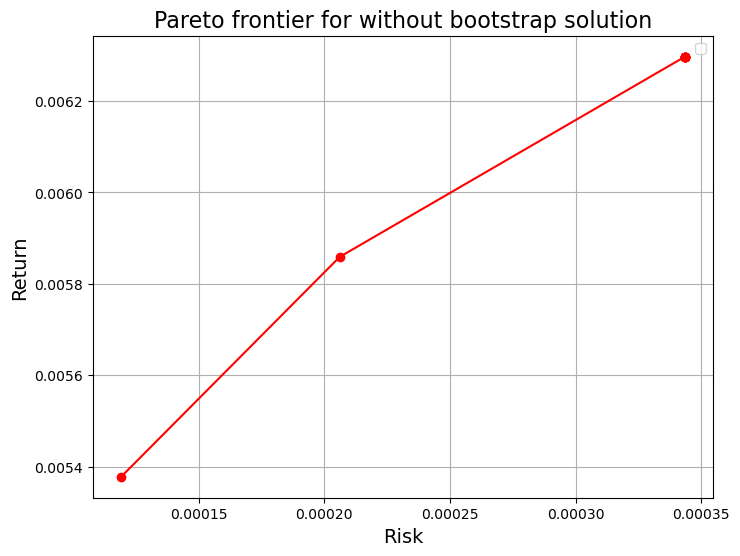

In [54]:
SRisk_No = [x for x,_ in sorted(zip(Risk_No,Retern_No))]
SRetern_No = [x for _,x in sorted(zip(Risk_No,Retern_No))]
#
plt.figure(figsize=(8,6))
plt.plot(SRisk_No, SRetern_No, color='red', marker='o', linestyle='-')
plt.xlabel('Risk', fontsize=14)
plt.ylabel('Return', fontsize=14)
plt.title('Pareto frontier for without bootstrap solution', fontsize=16)
plt.legend()
plt.grid(True)
plt.savefig(f'PF_No.jpg')
plt.show()
#files.download(f'PF_No.jpg')

In [55]:
meanr =np.mean(last_90_RD_clean, axis=0)[0:num_assets]
meanr.shape

(15,)

In [56]:
covariance_Matrixr =np.cov(last_90_RD_clean, rowvar=False)[0:num_assets,0:num_assets]
covariance_Matrixr.shape

(15, 15)

In [57]:
#Mean_Variance_Optimization
old_settings = solvers.options.copy()
solvers.options['show_progress'] = False
sigmar = covariance_Matrixr
P = matrix(sigmar, tc='d')
q = -matrix(meanr.astype(np.double), tc='d')
G = matrix(-np.eye(num_assets), tc='d')
h = matrix(np.zeros(num_assets), tc='d')
A = matrix(np.ones(num_assets), tc='d').T
b = matrix(1.0)
Optimal_valuer_Lambda =[]
Optimal_solutionr_Lambda =[]
for Lambda in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
  sol = solvers.qp(2*Lambda*P,(1-Lambda)*q,G,h,A,b)
  Optimal_valuer_Lambda.append(sol['primal objective'])
  Optimal_solutionr_Lambda.append(sol['x'])
solvers.options.update(old_settings)

In [58]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
X_OPT_r =[]
for i in range(9):
  print("lambda =", Lambda_list[i])
  X = np.zeros(num_assets)
  for j in range(num_assets):
    X[j] = Optimal_solutionr_Lambda[i][j]
  print(X)
  X_OPT_r.append(X)

lambda = 0.1
[6.04497373e-07 8.71317800e-08 9.99995854e-01 2.41527739e-07
 1.16979026e-07 3.85841364e-07 1.59112354e-07 1.09376409e-07
 5.64368886e-08 7.14158063e-07 1.94509233e-07 1.60293046e-07
 2.43568793e-07 4.28104721e-07 6.44880577e-07]
lambda = 0.2
[1.61943849e-06 1.58197653e-07 9.99994465e-01 3.23161319e-07
 1.98212248e-07 4.62661619e-07 2.52373380e-07 1.90086246e-07
 1.14754742e-07 5.28987795e-07 2.88254596e-07 2.41235893e-07
 2.10566910e-07 4.75099666e-07 4.72028262e-07]
lambda = 0.3
[2.68690052e-04 2.15737007e-07 9.99721659e-01 4.12755752e-07
 2.77038597e-07 5.90715578e-07 3.65665018e-07 2.69992119e-07
 1.63307462e-07 2.42329298e-07 4.02604905e-07 3.14519987e-07
 5.76220860e-06 5.47792853e-07 8.64113660e-08]
lambda = 0.4
[1.66708281e-01 3.84137615e-08 8.33247939e-01 7.58021025e-08
 4.62656053e-08 1.22930687e-07 5.79842491e-08 4.44189952e-08
 2.77275571e-08 3.87047682e-07 6.71919669e-08 5.67832055e-08
 4.24992437e-05 1.24330268e-07 2.32316265e-07]
lambda = 0.5
[2.66415383e-01

In [60]:
#Risk
Risk_r =[]
sigmar = covariance_Matrixr
for i in range(9):
   print("lambda =", Lambda_list[i])
   print(np.dot(X_OPT_r[i].T, sigmar @ X_OPT_r[i]))
   Risk_r.append(np.dot(X_OPT_r[i].T, sigmar @ X_OPT_r[i]))

#print(Risk_r)

lambda = 0.1
0.0005746269325937665
lambda = 0.2
0.0005746253075063574
lambda = 0.3
0.0005742995965230032
lambda = 0.4
0.00040511148232684843
lambda = 0.5
0.00030031318585709943
lambda = 0.6
0.00024361749634272187
lambda = 0.7
0.00021287975575865682
lambda = 0.8
0.00015589096064278846
lambda = 0.9
7.653479483629225e-05


In [61]:
#Retern
Retern_r =[]
for i in range(9):
  print("lambda =", Lambda_list[i])
  print(np.dot(meanr, X_OPT_r[i]))
  Retern_r.append(np.dot(meanr, X_OPT_r[i]))

#print(Retern_r)

lambda = 0.1
0.0021952387789821513
lambda = 0.2
0.0021952355704127086
lambda = 0.3
0.0021950824186483383
lambda = 0.4
0.002102825161686226
lambda = 0.5
0.002017339521812105
lambda = 0.6
0.00194923528268366
lambda = 0.7
0.0018909976964345807
lambda = 0.8
0.0017210591606281315
lambda = 0.9
0.0012614201075859185


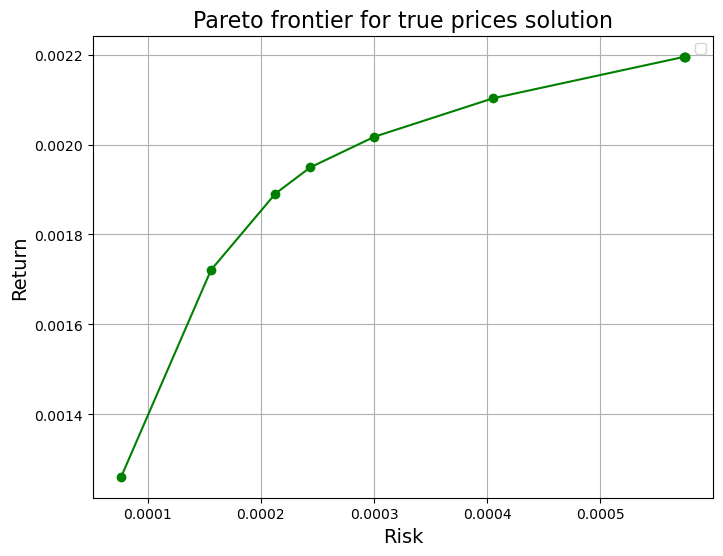

In [62]:
SRisk_r = [x for x,_ in sorted(zip(Risk_r,Retern_r))]
SRetern_r = [x for _,x in sorted(zip(Risk_r,Retern_r))]

plt.figure(figsize=(8,6))
plt.plot(SRisk_r, SRetern_r, color='green', marker='o', linestyle='-')
plt.xlabel('Risk', fontsize=14)
plt.ylabel('Return', fontsize=14)
plt.title('Pareto frontier for true prices solution', fontsize=16)
plt.legend()
plt.grid(True)
plt.savefig(f'PF_r.jpg')
plt.show()
#files.download(f'PF_r.jpg')

In [63]:
PD15 = np.asarray([sum(abs(Optimal_solution15_5[i]-X_OPT_r[i])) for i in range(9)])

In [64]:
PDNO = np.asarray([sum(abs(X_OPT_No[i]-X_OPT_r[i])) for i in range(9)])

In [65]:
np.mean(PD15), np.mean(PDNO)

(np.float64(1.741516991840298), np.float64(1.928571025406025))